# Selected-model validation comparison

This notebook compares three selected specifications on the chronological validation sample: market-only Ridge regression, market-only XGBoost, and Temporal GraphSAGE with hidden dimension 32 and dropout 0.20. Mean absolute error is evaluated across within-quarter deciles of realized forward maximum drawdown. The test sample is not accessed.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator, PercentFormatter
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.gnn_training import (
    _fit_with_validation,
    _load_graph_dataset,
    _new_model,
    _predict_temporal,
)
from src.modeling.tabular_selection import (
    TARGET,
    XGBOOST_MAX_ROUNDS,
    XGBOOST_PATIENCE,
    fit_preprocessor,
    load_sample,
    split_sample,
    transform_features,
)
from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
project = get_project_config()
modeling_tables = paths.tables / 'modeling'
set_matplotlib_style()

c:\Users\salio\PythonEnvironments\main_venv_py312\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Validation predictions

In [2]:
sample = load_sample(
    paths.processed / 'modeling' / 'modeling_sample.parquet',
    'market',
)
train, validation, _ = split_sample(sample)
train_y = train[TARGET].to_numpy(dtype=float)

ridge_preprocessing = fit_preprocessor(train, 'market', standardize=True)
ridge_train_x = transform_features(train, ridge_preprocessing)
ridge_validation_x = transform_features(validation, ridge_preprocessing)
ridge = Ridge(alpha=1.0).fit(ridge_train_x, train_y)
ridge_training_predictions = np.clip(ridge.predict(ridge_train_x), 0, 1)
ridge_predictions = np.clip(ridge.predict(ridge_validation_x), 0, 1)

xgb_preprocessing = fit_preprocessor(train, 'market', standardize=False)
xgb_train_x = transform_features(train, xgb_preprocessing)
xgb_validation_x = transform_features(validation, xgb_preprocessing)
xgboost = XGBRegressor(
    n_estimators=XGBOOST_MAX_ROUNDS,
    max_depth=3,
    min_child_weight=1,
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=XGBOOST_PATIENCE,
    random_state=project.seed,
    n_jobs=4,
    tree_method='hist',
    verbosity=0,
)
xgboost.fit(
    xgb_train_x,
    train_y,
    eval_set=[(xgb_train_x, train_y), (xgb_validation_x, validation[TARGET])],
    verbose=False,
)
xgboost_training_predictions = np.clip(xgboost.predict(xgb_train_x), 0, 1)
xgboost_predictions = np.clip(xgboost.predict(xgb_validation_x), 0, 1)

In [3]:
gnn_prediction_path = (
    modeling_tables / 'temporal_graphsage_hidden_32_validation_predictions.parquet'
)
if gnn_prediction_path.is_file():
    gnn_validation = pd.read_parquet(gnn_prediction_path)
else:
    graph_dataset = _load_graph_dataset(
        paths.processed / 'modeling' / 'gnn',
        {'train'},
        'validation',
    )
    _, gnn_state, _ = _fit_with_validation(
        'temporal_graphsage',
        graph_dataset,
        project.seed,
        hidden_size=32,
        dropout=0.20,
        learning_rate=0.001,
        weight_decay=0.0001,
    )
    gnn = _new_model('temporal_graphsage', hidden_size=32, dropout=0.20)
    gnn.load_state_dict(gnn_state)
    gnn_validation = _predict_temporal(
        gnn, graph_dataset, 'validation', hidden_size=32
    )
    gnn_validation.to_parquet(gnn_prediction_path, index=False)

In [4]:
tabular_keys = validation[['report_period', 'permno', TARGET]].copy()
prediction_frames = []
for model, predictions in (
    ('Ridge', ridge_predictions),
    ('XGBoost', xgboost_predictions),
):
    frame = tabular_keys.copy()
    frame['model'] = model
    frame['prediction'] = predictions
    prediction_frames.append(frame)

gnn_frame = gnn_validation[[
    'report_period', 'permno',
    'future_max_drawdown_63d', 'predicted_future_max_drawdown_63d',
]].rename(columns={
    'future_max_drawdown_63d': TARGET,
    'predicted_future_max_drawdown_63d': 'prediction',
})
gnn_frame['model'] = 'Temporal GraphSAGE'
prediction_frames.append(gnn_frame)
predictions = pd.concat(prediction_frames, ignore_index=True)

model_counts = predictions.groupby('model').size()
if model_counts.nunique() != 1:
    raise RuntimeError('The models do not cover the same validation observations.')

## Overall validation performance

For Temporal GraphSAGE, training MAE is the saved mean training L1 across quarterly graph snapshots at the validation-selected epoch.

In [5]:
gnn_performance = pd.read_csv(
    modeling_tables / 'temporal_graphsage_hidden_32_validation_performance.csv'
).iloc[0]
gnn_history = pd.read_csv(
    modeling_tables / 'temporal_graphsage_hidden_32_training_history.csv'
)
gnn_training_mae = gnn_history.loc[
    gnn_history['epoch'].eq(gnn_performance['best_epoch']),
    'training_l1',
].item()
training_mae = {
    'Ridge': mean_absolute_error(train_y, ridge_training_predictions),
    'XGBoost': mean_absolute_error(train_y, xgboost_training_predictions),
    'Temporal GraphSAGE': gnn_training_mae,
}

performance_rows = []
for model, group in predictions.groupby('model', sort=False):
    quarterly_correlations = (
        group.groupby('report_period')
        .apply(
            lambda quarter: quarter[TARGET].corr(
                quarter['prediction'], method='spearman'
            ),
            include_groups=False,
        )
    )
    performance_rows.append({
        'model': model,
        'observations': len(group),
        'quarters': group['report_period'].nunique(),
        'training_mae': training_mae[model],
        'mae': mean_absolute_error(group[TARGET], group['prediction']),
        'rmse': mean_squared_error(group[TARGET], group['prediction']) ** 0.5,
        'r2': r2_score(group[TARGET], group['prediction']),
        'mean_quarterly_spearman': quarterly_correlations.mean(),
    })

model_performance = pd.DataFrame(performance_rows).sort_values('mae')
model_performance.to_csv(
    modeling_tables / 'selected_models_validation_comparison.csv',
    index=False,
)
model_performance.rename(columns={
    'model': 'Model',
    'observations': 'Observations',
    'quarters': 'Quarters',
    'training_mae': 'Training MAE',
    'mae': 'Validation MAE',
    'rmse': 'Validation RMSE',
    'r2': 'Validation R2',
    'mean_quarterly_spearman': 'Mean quarterly Spearman',
}).to_latex(
    paths.tables / '04_05_selected_models_validation_comparison.tex',
    index=False,
    escape=True,
    float_format='%.4f',
    caption='Validation performance of the finalist predictive models.',
    label='tab:selected-models-validation-comparison',
)
display(model_performance.style.format({
    'observations': '{:,}',
    'quarters': '{:,}',
    'training_mae': '{:.4f}',
    'mae': '{:.4f}',
    'rmse': '{:.4f}',
    'r2': '{:.3f}',
    'mean_quarterly_spearman': '{:.3f}',
}))

,model,observations,quarters,training_mae,mae,rmse,r2,mean_quarterly_spearman
2,Temporal GraphSAGE,"29,716",7,0.0813,0.0941,0.1348,0.440,0.748
1,XGBoost,"29,716",7,0.0836,0.0951,0.1317,0.466,0.748
0,Ridge,"29,716",7,0.0869,0.0959,0.1337,0.449,0.747


## Mean absolute error by realized-drawdown decile

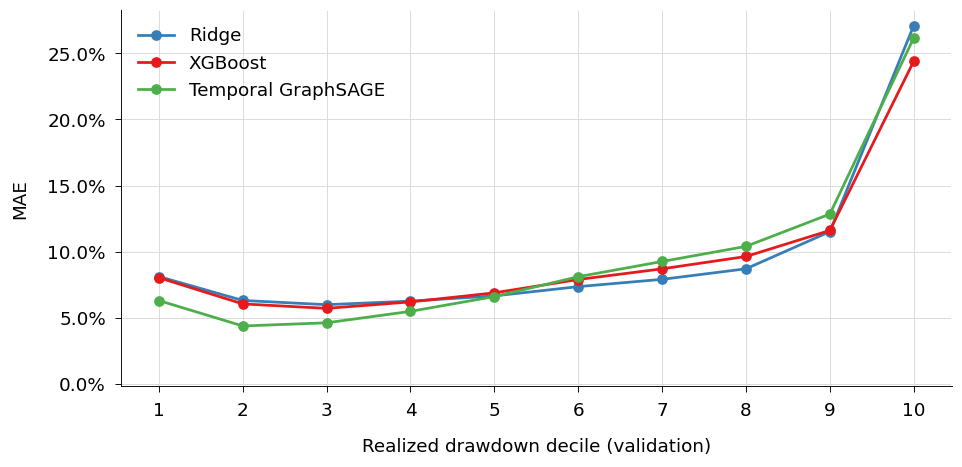

In [7]:
predictions['drawdown_rank'] = predictions.groupby(
    ['model', 'report_period']
)[TARGET].rank(method='first', pct=True)
predictions['drawdown_decile'] = np.ceil(
    10 * predictions['drawdown_rank']
).astype(int).clip(1, 10)
predictions['absolute_error'] = (
    predictions[TARGET] - predictions['prediction']
).abs()
decile_errors = (
    predictions.groupby(['model', 'drawdown_decile'], as_index=False)
    ['absolute_error'].mean()
)
decile_errors.to_csv(
    modeling_tables / 'selected_models_error_by_drawdown_decile.csv',
    index=False,
)
decile_errors.rename(columns={
    'model': 'Model',
    'drawdown_decile': 'Drawdown decile',
    'absolute_error': 'Mean absolute error',
}).to_latex(
    paths.tables / '04_05_selected_models_error_by_drawdown_decile.tex',
    index=False,
    escape=True,
    float_format='%.4f',
    caption='Validation mean absolute error by realized drawdown decile.',
    label='tab:selected-models-error-by-drawdown-decile',
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for index, model in enumerate(('Ridge', 'XGBoost', 'Temporal GraphSAGE')):
    rows = decile_errors.loc[decile_errors['model'].eq(model)]
    axis.plot(
        rows['drawdown_decile'],
        rows['absolute_error'],
        marker='o',
        color=COLOR_PALETTE[index],
        label=model,
    )
axis.set_xlabel('Realized drawdown decile (validation)')
axis.set_ylabel('MAE')
axis.set_ylim(bottom=-0.002)
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_07_validation_mae_by_realized_drawdown_decile.pdf'
)
plt.show()